In [1]:
import xarray as xr
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns
sns.set_style("whitegrid")


In [2]:
base = "outputs"

In [3]:

files = {
    "CRPS": {
        "temp": f"{base}/crps_allmodels_temp.csv",
        "precip": f"{base}/crps_allmodels_precip.csv"
    },
    "LSD": {
        "temp": f"{base}/lsd_allmodels_temp.csv",
        "precip": f"{base}/lsd_allmodels_precip.csv"
    },
    "PITD": {
        "temp": f"{base}/pitd_allmodels_temp.csv",
        "precip": f"{base}/pitd_allmodels_precip.csv"
    },
    "RMSE": {
        "temp": f"{base}/rmse_allmodels_temp.csv",
        "precip": f"{base}/rmse_allmodels_precip.csv"
    },
    "SSIM": {
        "temp": f"{base}/ssim_allmodels_temp.csv",
        "precip": f"{base}/ssim_allmodels_precip.csv"
    }
}

models = ["Coarse", "Bicubic", "UNet", "DDIM(11 samples)"]
metrics = ["CRPS ↓", "LSD ↓", "PITD ↓", "RMSE ↓", "SSIM ↑"]


In [4]:
def get_metric(file, col):
    df = pd.read_csv(file)
    if col not in df.columns:
        col = df.columns[1]
    return df.set_index(df.columns[0])[col].reindex(models).values


In [5]:
def collect_data(var):
    data = []
    for metric in metrics:
        if metric == "SSIM":
            # Use "SSIM" column for all models
            vals = get_metric(files[metric][var], "SSIM")
        elif metric == "RMSE":
            vals = get_metric(files[metric][var], "RMSE")
        else:
            vals = get_metric(files[metric][var], metric)
        data.append(vals)
    return np.array(data).T

In [6]:
def get_best_ddim(metric_file, best_col):
    df = pd.read_csv(metric_file)
    return df.loc[df.iloc[:,0] == "DDIM(11 samples)", best_col].values[0]

In [7]:
def inject_best(data, var):
    data = data.copy()
    # For temp
    if var == "temp":
        best_ssim = get_best_ddim(files["SSIM"]["temp"], "Best SSIM")
        best_rmse = get_best_ddim(files["RMSE"]["temp"], "Best RMSE")
        if not pd.isna(best_ssim):
            data[3, 4] = best_ssim  # SSIM is 5th col
        if not pd.isna(best_rmse):
            data[3, 3] = best_rmse  # RMSE is 4th col
    # For precip
    if var == "precip":
        best_ssim = get_best_ddim(files["SSIM"]["precip"], "Best SSIM")
        best_rmse = get_best_ddim(files["RMSE"]["precip"], "Best RMSE")
        if not pd.isna(best_ssim):
            data[3, 4] = best_ssim
        if not pd.isna(best_rmse):
            data[3, 3] = best_rmse
    return data


In [8]:
def plot_radar(data, title, metrics, models):
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the loop

    # Use tab10 for colorblind-friendly palette
    color_names = list(mcolors.TABLEAU_COLORS)
    colors = [mcolors.TABLEAU_COLORS[name] for name in color_names][:len(models)]

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    for i, model in enumerate(models):
        values = data[i].tolist()
        values += values[:1]
        ax.plot(angles, values, label=model, linewidth=3, color=colors[i])
        ax.fill(angles, values, alpha=0.15, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=16, fontweight='bold')

    ax.tick_params(axis='y', labelsize=13)
    ax.grid(True, linestyle='--', linewidth=1, alpha=0.7)

    ax.set_title(title, size=18, y=1.12, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=14, frameon=True)

    plt.figtext(0.5, 0.01, "↓: Lower is better   ↑: Higher is better", ha='center', fontsize=14, fontstyle='italic')
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=1000, bbox_inches='tight')
    plt.show()

In [9]:

metric_keys = ["CRPS", "LSD", "PITD", "RMSE", "SSIM"]
metrics = ["CRPS ↓", "LSD ↓", "PITD ↓", "RMSE ↓", "SSIM ↑"]

def collect_data(var):
    data = []
    for metric in metric_keys:
        if metric == "SSIM":
            vals = get_metric(files[metric][var], "SSIM")
        elif metric == "RMSE":
            vals = get_metric(files[metric][var], "RMSE")
        else:
            vals = get_metric(files[metric][var], metric)
        data.append(vals)
    return np.array(data).T



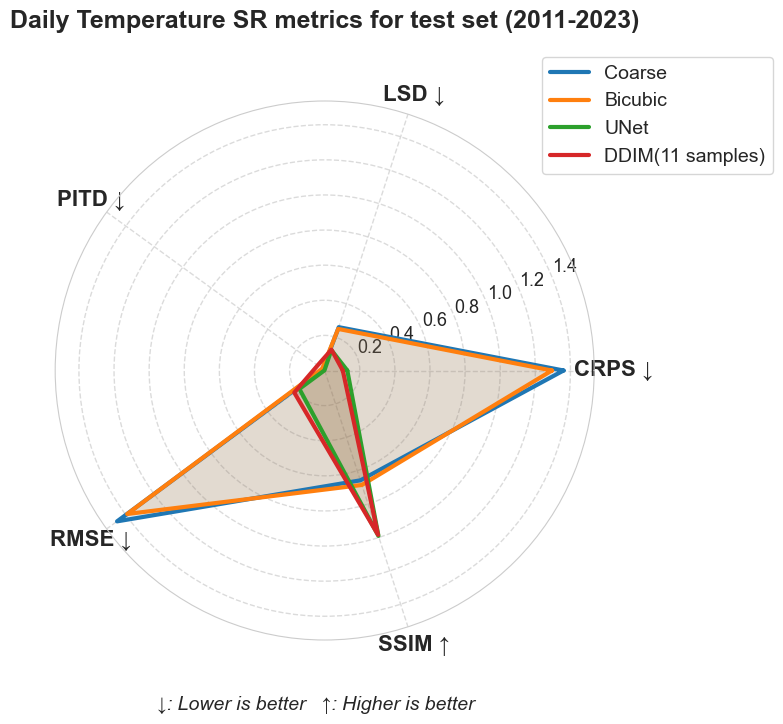

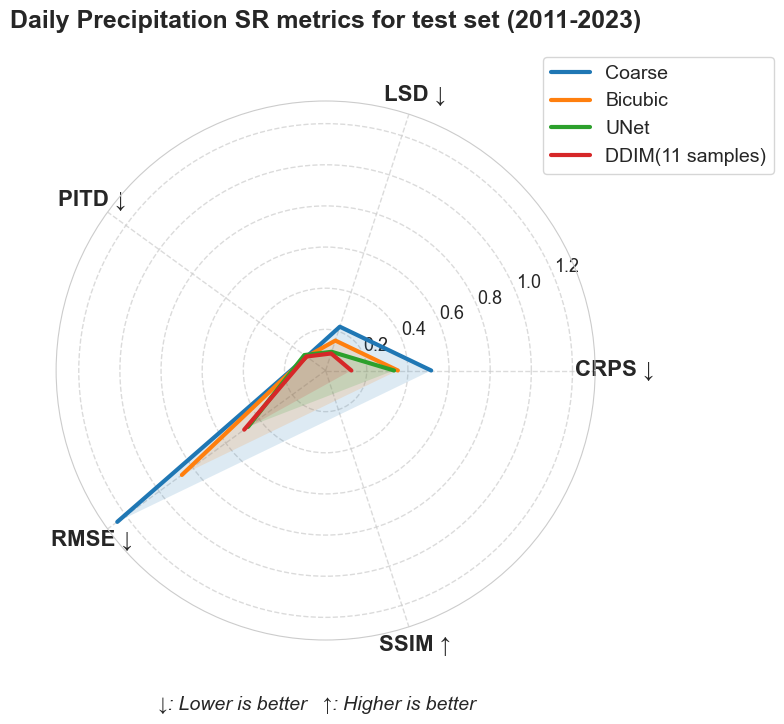

In [10]:

data_temp = collect_data("temp")
data_temp = inject_best(data_temp, "temp")

data_precip = collect_data("precip")
data_precip = inject_best(data_precip, "precip")

plot_radar(data_temp, "Daily Temperature SR metrics for test set (2011-2023)", metrics, models)
plot_radar(data_precip, "Daily Precipitation SR metrics for test set (2011-2023)", metrics, models)
